<a href="https://colab.research.google.com/github/JANASREE-P/24ADI006_24BAD040_DEEPLEARNING_E6/blob/main/DL_EXP6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
print("JANASREE 24BAD040")
# Load IMDB dataset
vocab_size = 10000
max_length = 200

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

# Display sample review and label
print("\nSample Review:")
print(X_train[0])

print("\nSample Label:")
print(y_train[0])

# Padding
X_train = pad_sequences(X_train, maxlen=max_length)
X_test = pad_sequences(X_test, maxlen=max_length)

print("\nAfter Padding:")
print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

# Create validation dataset
X_val = X_train[:5000]
y_val = y_train[:5000]

X_train_new = X_train[5000:]
y_train_new = y_train[5000:]

print("\nValidation shape:", X_val.shape)
print("Training shape:", X_train_new.shape)

JANASREE 24BAD040
Training samples: 25000
Testing samples: 25000

Sample Review:
[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16

In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding
print("JANASREE 24BAD040")
# Embedding parameters
embedding_dim = 64

print("Vocabulary Size:", vocab_size)
print("Embedding Dimension:", embedding_dim)

# Create Embedding layer
embedding_model = Sequential()

embedding_model.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        input_length=max_length
    )
)

# Generate embedding representation
embedding_output = embedding_model.predict(X_train_new[:1])

print("\nEmbedding Representation Shape:")
print(embedding_output.shape)

JANASREE 24BAD040
Vocabulary Size: 10000
Embedding Dimension: 64
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step

Embedding Representation Shape:
(1, 200, 64)


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
print("JANASREE 24BAD040")
# Create LSTM model
model = Sequential()

# Embedding layer
model.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        input_length=max_length
    )
)

# LSTM layer
model.add(LSTM(64))

# Output layer
model.add(Dense(1, activation='sigmoid'))

# Compile model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Display model architecture
model.summary()

JANASREE 24BAD040


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

JANASREE 24BAD040
Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 28s 85ms/step - accuracy: 0.7954 - loss: 0.4388 - val_accuracy: 0.8602 - val_loss: 0.3434
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 87ms/step - accuracy: 0.8989 - loss: 0.2579 - val_accuracy: 0.8498 - val_loss: 0.3378
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 87ms/step - accuracy: 0.9297 - loss: 0.1908 - val_accuracy: 0.8614 - val_loss: 0.3446
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 27s 87ms/step - accuracy: 0.9441 - loss: 0.1563 - val_accuracy: 0.8700 - val_loss: 0.3810
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 40s 84ms/step - accuracy: 0.9627 - loss: 0.1060 - val_accuracy: 0.8630 - val_loss: 0.4217
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.8554 - loss: 0.4530

Test Loss: 0.4530068337917328
Test Accuracy: 0.8553599715232849


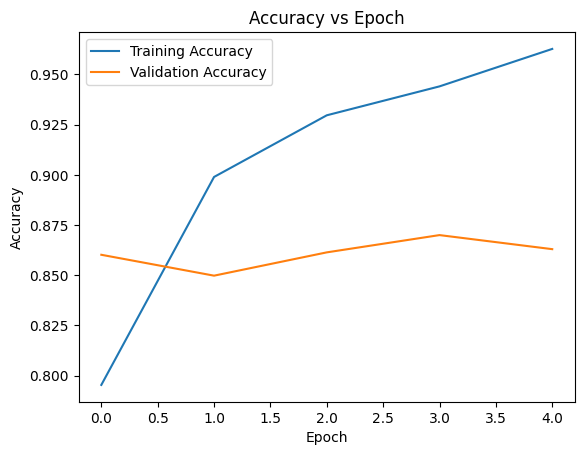

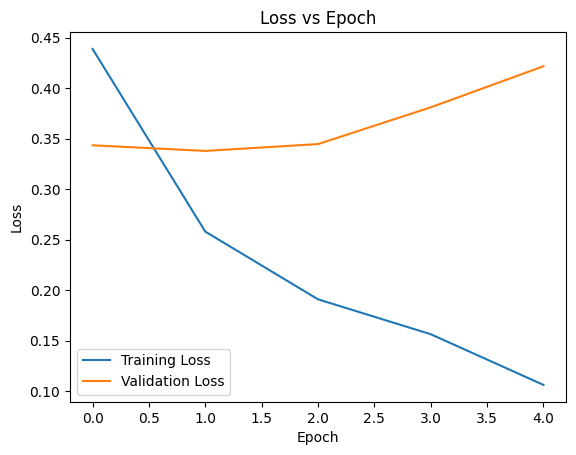

782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step

Evaluation Metrics
Accuracy : 0.85536
Precision: 0.8855902777777778
Recall   : 0.81616
F1 Score : 0.849458784346378

Confusion Matrix:
[[11182  1318]
 [ 2298 10202]]

Sample Predictions:
Actual: Negative | Predicted: Negative
Actual: Positive | Predicted: Positive
Actual: Positive | Predicted: Positive
Actual: Negative | Predicted: Positive
Actual: Positive | Predicted: Positive


In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score
from sklearn.metrics import recall_score, f1_score, confusion_matrix
print("JANASREE 24BAD040")
# Train the model
history = model.fit(
    X_train_new,
    y_train_new,
    epochs=5,
    batch_size=64,
    validation_data=(X_val, y_val)
)

# Evaluate model
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("\nTest Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

# Accuracy vs Epoch
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Training Accuracy", "Validation Accuracy"])
plt.show()

# Loss vs Epoch
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Training Loss", "Validation Loss"])
plt.show()

# Prediction
y_pred_probability = model.predict(X_test)

y_pred = (y_pred_probability >= 0.5).astype(int).flatten()

# Evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nEvaluation Metrics")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

# Compare actual and predicted sentiment
print("\nSample Predictions:")

for i in range(5):
    actual = "Positive" if y_test[i] == 1 else "Negative"
    predicted = "Positive" if y_pred[i] == 1 else "Negative"

    print("Actual:", actual, "| Predicted:", predicted)